# Random Forest Classifier

In [ ]:
#!pip install pandas numpy matplotlib scikit-learn -q
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json, os
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    classification_report, roc_auc_score, roc_curve,
    f1_score, precision_score, recall_score, accuracy_score
)
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 100
SEED = 42
print('Libraries loaded.')

## 1. Data Loading and Preprocessing

In [ ]:
def reduce_mem(df):
    for col in df.select_dtypes(include=['float64']).columns:
        df[col] = df[col].astype('float32')
    return df

train_trans = reduce_mem(pd.read_csv('data/train_transaction.csv'))
train_id    = reduce_mem(pd.read_csv('data/train_identity.csv'))
df = train_trans.merge(train_id, on='TransactionID', how='left')

START_DATE = pd.Timestamp('2017-11-30')
dt = START_DATE + pd.to_timedelta(df['TransactionDT'], unit='s')
df['tx_hour']  = dt.dt.hour.astype('int8')
df['tx_dow']   = dt.dt.dayofweek.astype('int8')
df['tx_month'] = dt.dt.month.astype('int8')
df['card_age'] = (df['TransactionDT'] // 86400 - df['D1']).astype('float32')
print(f'Merged shape: {df.shape}')

Merged shape: (590540, 438)


In [ ]:
df_sorted = df.sort_values('TransactionDT').reset_index(drop=True)
n       = len(df_sorted)
n_train = int(0.80 * n)
n_val   = int(0.10 * n)

train_df = df_sorted.iloc[:n_train].copy()
val_df   = df_sorted.iloc[n_train:n_train+n_val].copy()
test_df  = df_sorted.iloc[n_train+n_val:].copy()

y_train = train_df['isFraud'].values
y_val   = val_df['isFraud'].values
y_test  = test_df['isFraud'].values

print(f'Train : {len(train_df):,}  |  Val : {len(val_df):,}  |  Test : {len(test_df):,}')

CAT_COLS = [
    'ProductCD','card4','card6','P_emaildomain','R_emaildomain',
    'M1','M2','M3','M4','M5','M6','M7','M8','M9',
    'DeviceType','DeviceInfo',
    'id_12','id_15','id_16','id_23','id_27','id_28',
    'id_29','id_30','id_31','id_33','id_34','id_35','id_36','id_37','id_38'
]
CAT_COLS = [c for c in CAT_COLS if c in train_df.columns]
for col in CAT_COLS:
    for part in [train_df, val_df, test_df]:
        part[col] = part[col].fillna('unknown').astype(str)
    cats = train_df[col].unique().tolist()
    for part in [train_df, val_df, test_df]:
        part[col] = pd.Categorical(part[col], categories=cats).codes
print(f'Label-encoded {len(CAT_COLS)} columns.')

Train : 472,432  |  Val : 59,054  |  Test : 59,054
Label-encoded 31 columns.


In [ ]:
for part in [train_df, val_df, test_df]:
    part['uid'] = (part['card1'].astype(str) + '_' +
                   part['addr1'].fillna(-1).astype(int).astype(str) + '_' +
                   part['card_age'].fillna(-1).round(0).astype(int).astype(str))

c_cols    = [f'C{i}' for i in range(1, 15)]
uid_stats = (train_df.groupby('uid')
               .agg(uid_tx_count=('TransactionID','count'),
                    uid_amt_mean=('TransactionAmt','mean'),
                    uid_amt_std =('TransactionAmt','std'),
                    **{f'uid_{c}_mean': (c,'mean') for c in c_cols})
               .reset_index())
fallback = {
    'uid_tx_count': 1,
    'uid_amt_mean': float(train_df['TransactionAmt'].mean()),
    'uid_amt_std' : float(train_df['TransactionAmt'].std()),
    **{f'uid_{c}_mean': float(train_df[c].mean()) for c in c_cols},
}

def attach_uid(df_part, stats, fb):
    out = df_part.merge(stats, on='uid', how='left')
    for col, val in fb.items():
        out[col] = out[col].fillna(val).astype('float32')
    return out.drop(columns=['uid'])

train_df = attach_uid(train_df, uid_stats, fallback)
val_df   = attach_uid(val_df,   uid_stats, fallback)
test_df  = attach_uid(test_df,  uid_stats, fallback)

# RF uses BASELINE_FEATURES with imputation
BASELINE_FEATURES = (
    ['TransactionAmt'] +
    ['card1','card2','card3','card5','card4','card6'] +
    ['addr1','addr2','dist1','P_emaildomain','R_emaildomain'] +
    [f'C{i}' for i in range(1,15)] +
    ['D1','D2','D4','D10','D15'] +
    ['M1','M2','M3','M4','M5','M6','M7','M8','M9','ProductCD'] +
    ['tx_hour','tx_dow','tx_month','card_age'] +
    ['uid_tx_count','uid_amt_mean','uid_amt_std'] +
    [f'uid_C{i}_mean' for i in range(1,15)]
)
BASELINE_FEATURES = [f for f in BASELINE_FEATURES if f in train_df.columns]

def _base(df_part):
    X = df_part[BASELINE_FEATURES].copy()
    X['TransactionAmt'] = np.log1p(X['TransactionAmt'])
    return X

imputer   = SimpleImputer(strategy='median')
X_train_b = pd.DataFrame(imputer.fit_transform(_base(train_df)), columns=BASELINE_FEATURES)
X_val_b   = pd.DataFrame(imputer.transform(_base(val_df)),        columns=BASELINE_FEATURES)
X_test_b  = pd.DataFrame(imputer.transform(_base(test_df)),       columns=BASELINE_FEATURES)
print(f'Features (imputed): {len(BASELINE_FEATURES)}')

NameError: name 'train_df' is not defined

## 2. Random Forest

`class_weight='balanced_subsample'` reweights each bootstrap sample by class frequency -- more robust than `balanced` under heavy imbalance. `min_samples_leaf=50` prevents tiny fraud-only leaves. No early stopping; n_estimators=300 is sufficient for stable OOB error.

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=50,
    max_features='sqrt',
    class_weight='balanced_subsample',
    n_jobs=-1,
    random_state=SEED
)
print('Fitting RF (may take a few minutes)...')
rf_model.fit(X_train_b, y_train)
print('Done.')

y_prob_rf_val = rf_model.predict_proba(X_val_b)[:, 1]
y_prob_rf     = rf_model.predict_proba(X_test_b)[:, 1]

thr = np.linspace(y_prob_rf_val.min()+1e-4, y_prob_rf_val.max()-1e-4, 300)
best_rf = float(thr[int(np.argmax(
    [f1_score(y_val, (y_prob_rf_val>=t).astype(int), zero_division=0) for t in thr]
))])
y_pred_rf = (y_prob_rf >= best_rf).astype(int)
print(f'Threshold (val): {best_rf:.4f}')

print('='*35)
print('Random Forest -- Test Set')
print('='*35)
print(classification_report(y_test, y_pred_rf, target_names=['Legitimate','Fraud']))
print(f'AUC-ROC : {roc_auc_score(y_test, y_prob_rf):.4f}')

Fitting RF (may take a few minutes)...
Done.
Threshold (val): 0.7454
Random Forest -- Test Set
              precision    recall  f1-score   support

  Legitimate       0.98      0.99      0.98     56841
       Fraud       0.55      0.38      0.45      2213

    accuracy                           0.97     59054
   macro avg       0.76      0.68      0.71     59054
weighted avg       0.96      0.97      0.96     59054

AUC-ROC : 0.8802


## 3. Results

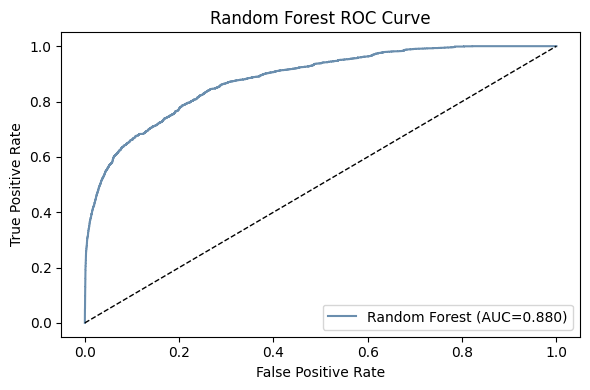

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_prob_rf)
auc = roc_auc_score(y_test, y_prob_rf)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(fpr, tpr, color='#6A8EAE', label=f'Random Forest (AUC={auc:.3f})')
ax.plot([0,1],[0,1],'k--',linewidth=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Random Forest ROC Curve')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
os.makedirs('results', exist_ok=True)

metrics = {
    'model'    : 'Random Forest',
    'accuracy' : float(accuracy_score(y_test, y_pred_rf)),
    'precision': float(precision_score(y_test, y_pred_rf, zero_division=0)),
    'recall'   : float(recall_score(y_test, y_pred_rf, zero_division=0)),
    'f1'       : float(f1_score(y_test, y_pred_rf, zero_division=0)),
    'auc'      : float(roc_auc_score(y_test, y_prob_rf)),
    'threshold': best_rf,
}
with open('results/rf_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)
np.save('results/rf_probs.npy',     y_prob_rf)
np.save('results/rf_val_probs.npy', y_prob_rf_val)
print('Saved results/rf_metrics.json, rf_probs.npy, rf_val_probs.npy')
print(json.dumps(metrics, indent=2))

Saved results/rf_metrics.json, rf_probs.npy, rf_val_probs.npy
{
  "model": "Random Forest",
  "accuracy": 0.96501507095201,
  "precision": 0.5481335952848723,
  "recall": 0.3782196113872571,
  "f1": 0.4475935828877005,
  "auc": 0.880247115623255,
  "threshold": 0.7453636061333498
}


## 4. Comparison to Baselines

Comparison Table (test set):
                     Precision (Fraud)  Recall (Fraud)  F1 (Fraud)   AUC-ROC
Logistic Regression           0.232261        0.221871    0.226947  0.795937
Naive Bayes                   0.189313        0.297786    0.231472  0.750210
Random Forest                 0.548100        0.378200    0.447600  0.880200


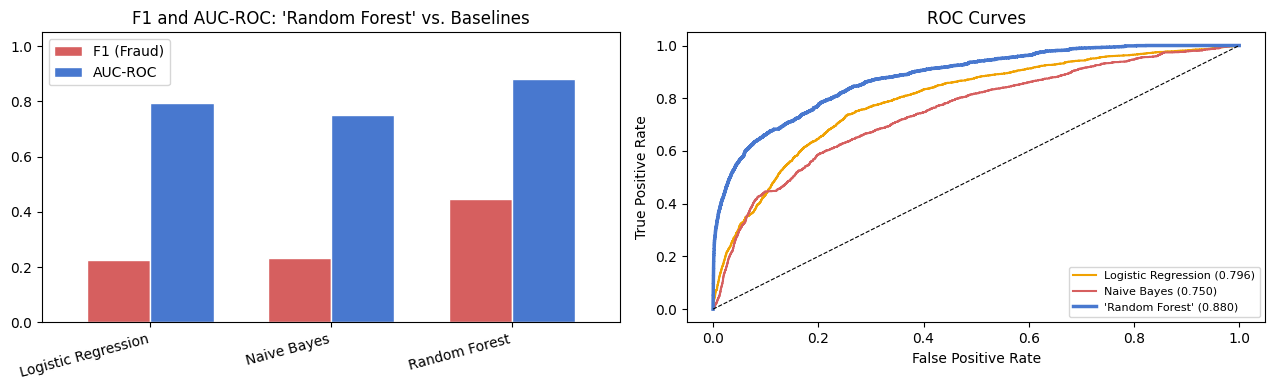

In [ ]:
# Load metrics from previously run notebooks
BASELINE_FILES = {
    'Logistic Regression': 'results/lr_metrics.json',
    'Naive Bayes'        : 'results/nb_metrics.json',
}

def load_metrics(path):
    try:
        with open(path) as f:
            return json.load(f)
    except FileNotFoundError:
        return None

def load_probs(path):
    try:
        return np.load(path)
    except FileNotFoundError:
        return None

rows = {}
prob_files = {
    'Logistic Regression': 'results/lr_probs.npy',
    'Naive Bayes'        : 'results/nb_probs.npy',
}
for name, path in BASELINE_FILES.items():
    m = load_metrics(path)
    if m:
        rows[name] = {
            'Precision (Fraud)': m['precision'],
            'Recall (Fraud)'   : m['recall'],
            'F1 (Fraud)'       : m['f1'],
            'AUC-ROC'          : m['auc'],
        }

rows['Random Forest'] = {
    'Precision (Fraud)': round(float(precision_score(y_test, y_pred_rf, zero_division=0)), 4),
    'Recall (Fraud)'   : round(float(recall_score(y_test, y_pred_rf, zero_division=0)), 4),
    'F1 (Fraud)'       : round(float(f1_score(y_test, y_pred_rf, zero_division=0)), 4),
    'AUC-ROC'          : round(float(roc_auc_score(y_test, y_prob_rf)), 4),
}

cmp_df = pd.DataFrame(rows).T
print('Comparison Table (test set):')
print(cmp_df.to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Bar chart
cmp_df[['F1 (Fraud)','AUC-ROC']].plot(
    kind='bar', ax=axes[0], color=['#D65F5F','#4878CF'], edgecolor='white', width=0.7)
axes[0].set_title("F1 and AUC-ROC: 'Random Forest' vs. Baselines")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=15, ha='right')
axes[0].set_ylim(0, 1.05)
axes[0].legend()

# ROC curves
COLORS_CMP = ['#F0A202', '#D65F5F', '#808080', '#4878CF']
baseline_probs = {k: load_probs(v) for k, v in prob_files.items()}
for i, (name, yp) in enumerate(baseline_probs.items()):
    if yp is not None:
        fpr, tpr, _ = roc_curve(y_test, yp)
        axes[1].plot(fpr, tpr, color=COLORS_CMP[i], linewidth=1.5,
                     label=f"{name} ({rows[name]['AUC-ROC']:.3f})")
fpr, tpr, _ = roc_curve(y_test, y_prob_rf)
axes[1].plot(fpr, tpr, color='#4878CF', linewidth=2.5,
             label=f"'Random Forest' ({rows['Random Forest']['AUC-ROC']:.3f})")
axes[1].plot([0,1],[0,1],'k--',linewidth=0.8)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves')
axes[1].legend(loc='lower right', fontsize=8)

plt.tight_layout()
plt.show()